Rolling 20-day average daily return (mu): 0.003466
Rolling 20-day daily volatility (sigma): 0.013576


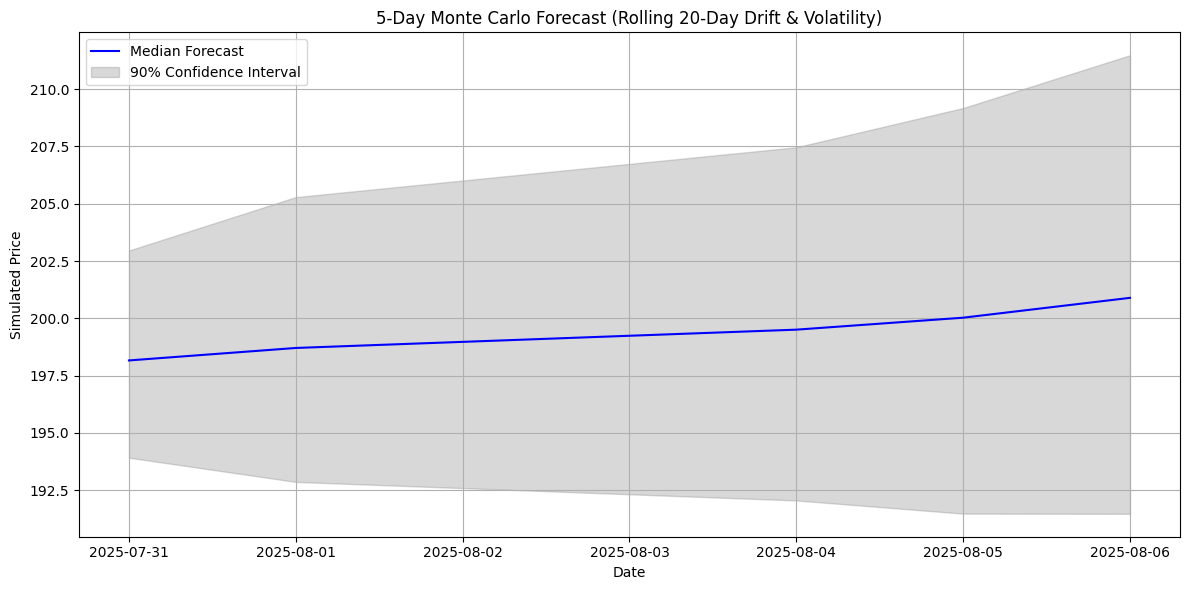

✅ Forecast saved to montecarlo_5day_rolling_forecast.csv


In [2]:
# === Monte Carlo Price Path Forecast using 20-day Rolling μ and σ ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# === Load Cleaned Data ===
data = pd.read_csv("GOOG_C_cleaned.csv", parse_dates=['Date'], index_col='Date')
prices = data['Close']

# === Calculate Log Returns ===
log_returns = np.log(prices / prices.shift(1)).dropna()

# === Use 20-day rolling window for mu and sigma ===
mu = log_returns[-30:].mean()
sigma = log_returns[-30:].std()

print(f"Rolling 20-day average daily return (mu): {mu:.6f}")
print(f"Rolling 20-day daily volatility (sigma): {sigma:.6f}")

# === Monte Carlo Simulation Parameters ===
S0 = prices.iloc[-1]              # Most recent price
days = 5                          # Forecast horizon
simulations = 1000                # Number of paths
confidence_level = 0.95
alpha = (1 - confidence_level) / 2

# === Run Monte Carlo Simulation ===
simulated_paths = np.zeros((days, simulations))

for i in range(simulations):
    shocks = np.random.normal(loc=(mu - 0.5 * sigma**2), scale=sigma, size=days)
    price_path = S0 * np.exp(np.cumsum(shocks))
    simulated_paths[:, i] = price_path

# === Build Forecast DataFrame ===
forecast_dates = pd.date_range(start=data.index[-1], periods=days + 1, freq='B')[1:]
forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'MedianForecast': np.median(simulated_paths, axis=1),
    'LowerBound_5%': np.percentile(simulated_paths, 5, axis=1),
    'UpperBound_95%': np.percentile(simulated_paths, 95, axis=1)
})
forecast_df.set_index('Date', inplace=True)

# === Plot Forecast ===
plt.figure(figsize=(12, 6))
plt.plot(forecast_df['MedianForecast'], label='Median Forecast', color='blue')
plt.fill_between(forecast_df.index,
                 forecast_df['LowerBound_5%'],
                 forecast_df['UpperBound_95%'],
                 color='gray', alpha=0.3, label='90% Confidence Interval')
plt.title(f'{days}-Day Monte Carlo Forecast (Rolling 20-Day Drift & Volatility)')
plt.xlabel("Date")
plt.ylabel("Simulated Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Export to CSV ===
forecast_df.to_csv("montecarlo_5day_rolling_forecast.csv")
print("✅ Forecast saved to montecarlo_5day_rolling_forecast.csv")
